# Data Project

> **Note:** 
> 1. This is a starting point for how to structure your data project 
> 1. The `dataproject.py` file includes functions which can be in this notebook

Import and set magics:

In [71]:
#%pip install git+https://github.com/alemartinello/dstapi

import numpy as np
import pandas as pd

# APIs
#from dstapi import DstApi

# plotting
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

from scipy.optimize import minimize

## Question 1

We load relevant data:

In [ ]:
# APIs
from dstapi import DstApi

In [2]:
IFOR41 = DstApi('IFOR41') 

Info about the variables:

In [96]:
IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


From this we see that All Denmark = 000 and ULLIG=70

In [97]:
# a. Set the parameters for the data we want to download
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},       # Gini coefficient
        {'code': 'KOMMUNEDK', 'values': ['000']},  # All Denmark
        {'code': 'Tid', 'values': ['*']}           # all years
    ]
}

# b. downloads the data into a pandas DataFrame
Gini = IFOR41.get_data(params=params)

# c. Set the correct data types and sort the observations by year
Gini['TID'] = Gini['TID'].astype(int)
Gini['INDHOLD'] = Gini['INDHOLD'].astype(float)
Gini = Gini.set_index('TID').sort_index()

# d. display
display(Gini.head(5))
display(Gini.info())

,ULLIG,KOMMUNEDK,INDHOLD
TID,,,
1987,Gini coefficient,All Denmark,22.07
1988,Gini coefficient,All Denmark,22.06
1989,Gini coefficient,All Denmark,21.93
1990,Gini coefficient,All Denmark,22.16
1991,Gini coefficient,All Denmark,21.99


<class 'pandas.core.frame.DataFrame'>
Index: 38 entries, 1987 to 2024
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ULLIG      38 non-null     object 
 1   KOMMUNEDK  38 non-null     object 
 2   INDHOLD    38 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.2+ KB


None

We see that the data is sorted

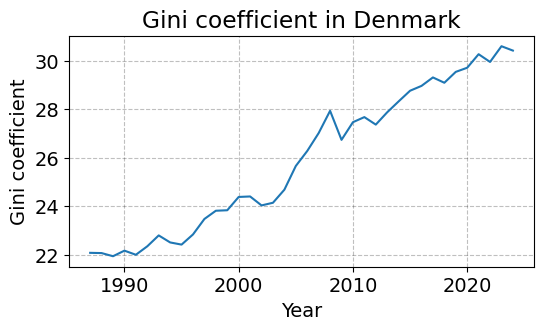

In [98]:
fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111)

ax.plot(Gini.index, Gini['INDHOLD'])

ax.set_title('Gini coefficient in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

plt.show()

Download IFOR32:

In [38]:
# Connect to table IFOR32
IFOR32 = DstApi('IFOR32')

# Check the variables and their values
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [41]:
# a. Set download parameters
params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},       # All 10 income deciles
        {'code': 'KOMMUNEDK', 'values': ['000']},    # All Denmark
        {'code': 'Tid', 'values': ['*']}             # All years
    ]
}

# b. Download the data
Deciles = IFOR32.get_data(params=params)

# c. Set types and sort
Deciles['TID'] = Deciles['TID'].astype(int)
Deciles['INDHOLD'] = Deciles['INDHOLD'].astype(float)
Deciles = Deciles.sort_values(['TID', 'DECILGEN'])

# d. Display the first observations
display(Deciles.head(10))
display(Deciles.info())

,DECILGEN,KOMMUNEDK,TID,INDHOLD
267,Eigth decil,All Denmark,1987,110184.0
264,Fifth decil,All Denmark,1987,85361.0
260,First decil,All Denmark,1987,31418.0
263,Fourth decil,All Denmark,1987,77577.0
268,Ninth decil,All Denmark,1987,123582.0
261,Second decil,All Denmark,1987,59014.0
266,Seventh decil,All Denmark,1987,100691.0
265,Sixth decil,All Denmark,1987,92777.0
269,Tenth decil,All Denmark,1987,169598.0
262,Third decil,All Denmark,1987,68786.0


<class 'pandas.core.frame.DataFrame'>
Index: 380 entries, 267 to 203
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   DECILGEN   380 non-null    object 
 1   KOMMUNEDK  380 non-null    object 
 2   TID        380 non-null    int64  
 3   INDHOLD    380 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 14.8+ KB


None

In [49]:
# Calculate the top 10% income share for each year by dividing average income of tenth decile by total income of all deciles
Top10 = Deciles.groupby('TID').apply(
    lambda x: x.loc[x['DECILGEN'] == 'Tenth decil', 'INDHOLD'].iloc[0] / x['INDHOLD'].sum()
)

# Convert to percentage
Top10 = Top10 * 100

# Set year as the index
Top10 = Top10.sort_index()

display(Top10.head())

/var/folders/vx/xr1r5zt16cz0d84mb3n5lf2m0000gn/T/ipykernel_47996/3805307097.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  Top10 = Deciles.groupby('TID').apply(


TID
1987    18.454866
1988    18.428870
1989    18.495170
1990    18.641480
1991    18.668346
dtype: float64

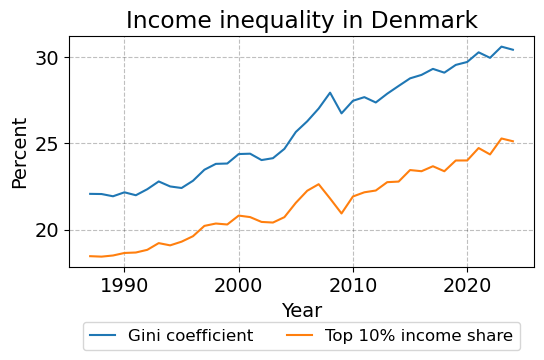

In [60]:
# Combine the Gini coefficient and top 10% income share by year
df = pd.concat([
    Gini['INDHOLD'].rename('Gini'),
    Top10.rename('Top 10% share')
], axis=1)

# Plot both measures over time
fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111)

ax.plot(df.index, df['Gini'], label='Gini coefficient')
ax.plot(df.index, df['Top 10% share'], label='Top 10% income share')

ax.set_title('Income inequality in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Percent')
ax.legend()
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=12, handlelength=1.5)


plt.show()

In [ ]:
#how to I get this to work!!!
merged = pd.merge(Gini, Top10, on='YEAR', validate='1:1')

Q 1.2

In [75]:
from scipy.optimize import minimize
import numpy as np

# t is the number of years since 1987
t = Gini.index - 1987
y = Gini['INDHOLD']

# Define the sum of squared errors for a polynomial of degree p
def objective(beta, t, y, p):
    prediction = sum(beta[k] * t**k for k in range(p + 1))
    return np.sum((y - prediction)**2)

# p = 1: linear trend
linear = minimize(objective, np.zeros(2), args=(t, y, 1))

# p = 2: quadratic trend
quadratic = minimize(objective, np.zeros(3), args=(t, y, 2))

print("Linear coefficients:", linear.x)
print("Quadratic coefficients:", quadratic.x)

Linear coefficients: [21.04275354  0.26354959]
Quadratic coefficients: [2.13041883e+01 2.19976116e-01 1.17766330e-03]


In [77]:
# Check the linear trend
polyfit_linear = np.polyfit(t, y, 1)

# Check the quadratic trend
polyfit_quadratic = np.polyfit(t, y, 2)

print("Linear:")
print("minimize:", linear.x)
print("polyfit:", polyfit_linear[::-1])

print("Quadratic:")
print("minimize:", quadratic.x)
print("polyfit:", polyfit_quadratic[::-1])

Linear:
minimize: [21.04275354  0.26354959]
polyfit: [21.04275304  0.26354962]
Quadratic:
minimize: [2.13041883e+01 2.19976116e-01 1.17766330e-03]
polyfit: [2.13042004e+01 2.19975061e-01 1.17769085e-03]


In [78]:
# Prediction years
t_pred = np.array([2030 - 1987, 2040 - 1987])

# Linear predictions
linear_pred = linear.x[0] + linear.x[1] * t_pred

# Quadratic predictions
quadratic_pred = quadratic.x[0] + quadratic.x[1] * t_pred + quadratic.x[2] * t_pred**2

print("Linear predictions:", linear_pred)
print("Quadratic predictions:", quadratic_pred)

Linear predictions: [32.37538612 35.01088207]
Quadratic predictions: [32.94066071 36.27097864]


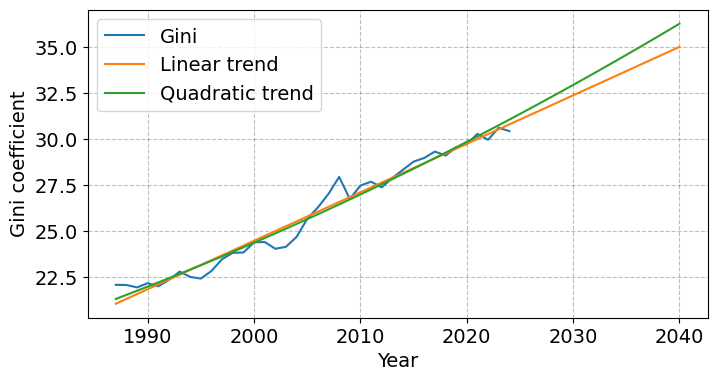

In [79]:
years = np.arange(1987, 2041)
t_plot = years - 1987

linear_fit = linear.x[0] + linear.x[1] * t_plot
quadratic_fit = quadratic.x[0] + quadratic.x[1] * t_plot + quadratic.x[2] * t_plot**2

plt.figure(figsize=(8, 4))
plt.plot(Gini.index, Gini['INDHOLD'], label='Gini')
plt.plot(years, linear_fit, label='Linear trend')
plt.plot(years, quadratic_fit, label='Quadratic trend')

plt.xlabel('Year')
plt.ylabel('Gini coefficient')
plt.legend()
plt.show()

1.3

In [99]:
# a. Set the parameters for the data we want to download

params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},       # Gini coefficient
        {'code': 'KOMMUNEDK', 'values': ['*']},    # All municipalities
        {'code': 'Tid', 'values': ['*']}            # All years
    ]
}

# b. Download the data into a pandas DataFrame

Gini_municipal = IFOR41.get_data(params=params)

# c. Set the correct data types and sort

Gini_municipal['TID'] = Gini_municipal['TID'].astype(int)
Gini_municipal['INDHOLD'] = Gini_municipal['INDHOLD'].astype(float)
Gini_municipal = Gini_municipal.sort_values(['KOMMUNEDK', 'TID'])

# d. Display

display(Gini_municipal.head())
Gini_municipal.info()

,ULLIG,KOMMUNEDK,TID,INDHOLD
1649,Gini coefficient,Aabenraa,1987,21.33
263,Gini coefficient,Aabenraa,1988,21.51
461,Gini coefficient,Aabenraa,1989,20.74
3035,Gini coefficient,Aabenraa,1990,20.83
2540,Gini coefficient,Aabenraa,1991,20.86


<class 'pandas.core.frame.DataFrame'>
Index: 3762 entries, 1649 to 3521
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ULLIG      3762 non-null   object 
 1   KOMMUNEDK  3762 non-null   object 
 2   TID        3762 non-null   int64  
 3   INDHOLD    3762 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 147.0+ KB


In [102]:
# a. Set download parameters
params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},       # All 10 income deciles
        {'code': 'KOMMUNEDK', 'values': ['*']},    # All Denmark
        {'code': 'Tid', 'values': ['*']}             # All years
    ]
}

# b. Download the data
Deciles_municipal = IFOR32.get_data(params=params)

# c. Set types and sort
Deciles_municipal['TID'] = Deciles_municipal['TID'].astype(int)
Deciles_municipal['INDHOLD'] = Deciles_municipal['INDHOLD'].astype(float)
Deciles_municipal = Deciles_municipal.sort_values(['TID', 'DECILGEN'])

# d. Display the first observations
display(Deciles_municipal.head(10))
display(Deciles_municipal.info())

,DECILGEN,KOMMUNEDK,TID,INDHOLD
20859,Eigth decil,Hillerød,1987,125744.0
20869,Eigth decil,Hørsholm,1987,159216.0
20879,Eigth decil,Rudersdal,1987,152188.0
25531,Eigth decil,Egedal,1987,128596.0
25541,Eigth decil,Frederikssund,1987,119737.0
25551,Eigth decil,Greve,1987,129698.0
25561,Eigth decil,Køge,1987,116496.0
25571,Eigth decil,Halsnæs,1987,113838.0
25581,Eigth decil,Roskilde,1987,121737.0
25591,Eigth decil,Solrød,1987,128399.0


<class 'pandas.core.frame.DataFrame'>
Index: 37620 entries, 20859 to 19271
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   DECILGEN   37620 non-null  object 
 1   KOMMUNEDK  37620 non-null  object 
 2   TID        37620 non-null  int64  
 3   INDHOLD    37620 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.4+ MB


None

In [107]:
Top10_muni = Deciles.groupby(['KOMMUNEDK', 'TID']).apply(lambda x: x.loc[x['DECILGEN'] == 'Tenth decil', 'INDHOLD'].iloc[0] / x['INDHOLD'].sum()).reset_index(name='Top10')

/var/folders/vx/xr1r5zt16cz0d84mb3n5lf2m0000gn/T/ipykernel_47996/2380364826.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  Top10_muni = Deciles.groupby(['KOMMUNEDK', 'TID']).apply(lambda x: x.loc[x['DECILGEN'] == 'Tenth decil', 'INDHOLD'].iloc[0] / x['INDHOLD'].sum()).reset_index(name='Top10')


In [108]:
Top10_muni['Top10'].describe()

count    38.000000
mean      0.214501
std       0.020779
min       0.184289
25%       0.197636
50%       0.212417
75%       0.232317
max       0.252823
Name: Top10, dtype: float64

In [109]:
Municipal = pd.merge(Gini_municipal, Top10_muni, on=['KOMMUNEDK', 'TID'], validate='1:1')

In [111]:
Municipal[['INDHOLD', 'Top10']].corr()

,INDHOLD,Top10
INDHOLD,1.000000,0.981642
Top10,0.981642,1.000000


## Question 2

We process the data by ...

In [ ]:
data = dataproject.process_data(data)

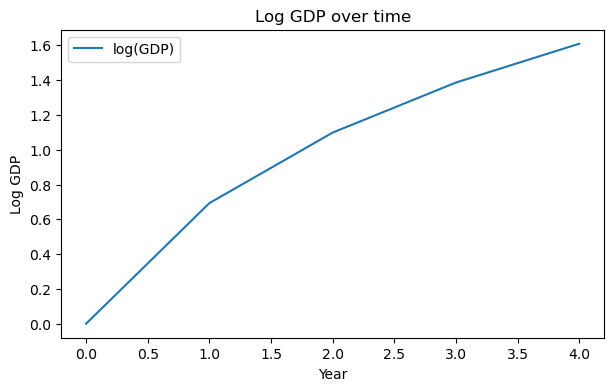

In [ ]:
fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)

ax.plot(data['log_GDP'],label='log(GDP)')

ax.set_title('Log GDP over time')
ax.set_xlabel('Year')
ax.set_ylabel('Log GDP')

ax.legend();

We find that that ...